# Credit Risk Intelligence Platform
## Notebook 4 — SHAP Explainability + AI Credit Memo

**What this notebook does:**
1. SHAP global explainability
2. SHAP local explainability
3. Per-persona SHAP analysis — do different personas default for different reasons?
4. AI-generated credit officer memo via Groq API (Layer 5)



In [21]:
import subprocess
subprocess.run(['pip', 'install', 'groq', 'python-dotenv', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
from groq import Groq

os.makedirs('./outputs', exist_ok=True)
os.makedirs('./outputs/memos', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
})
ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'
BLUE   = '#56b4e9'

print("  Imports done")

  Imports done


## API Key Setup

Loads `GROQ_API_KEY` from a `.env` file in the project root.
Create a `.env` file one level above this notebook with:
```
GROQ_API_KEY=your_key_here
```

In [22]:
load_dotenv('../.env')
API_KEY = os.getenv('GROQ_API_KEY')

if API_KEY is None:
    raise ValueError(
        "GROQ_API_KEY not found.\n"
        "Create a .env file in the project root with: GROQ_API_KEY=your_key_here"
    )

print(" API key loaded successfully")

 API key loaded successfully


## Load Model & Data

In [28]:
best_model    = joblib.load('./outputs/best_model.pkl')
opt_threshold = np.load('./outputs/optimal_threshold.npy')[0]

data = np.load('./data/features.npz', allow_pickle=True)
X             = data['X']
y             = data['y']
feature_names = np.load('./data/feature_names.npy', allow_pickle=True).tolist()
df            = pd.read_csv('./data/df_featured.csv')

# Same split as notebook 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
_, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y
)
df_test = df.loc[test_idx].reset_index(drop=True)

print(f"    Model:     {type(best_model).__name__}")
print(f"    Threshold: {opt_threshold:.3f}")
print(f"    Test rows: {X_test.shape[0]:,}")

    Model:     XGBClassifier
    Threshold: 0.385
    Test rows: 6,336


## Step 1 — Compute SHAP Values

TreeExplainer is exact and fast for XGBoost.

SHAP value interpretation:
- **Positive value** → pushes prediction toward DEFAULT
- **Negative value** → pushes prediction toward NO DEFAULT
- **Magnitude** → how strongly it pushes

In [24]:
print("Computing SHAP values — 1-2 minutes...")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# XGBoost returns single array (not list of 2)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"  SHAP values computed")
print(f"    Shape: {sv.shape}")
print(f"    Positive = pushes toward default")
print(f"    Negative = pushes toward no default")

Computing SHAP values — 1-2 minutes...
  SHAP values computed
    Shape: (6336, 31)
    Positive = pushes toward default
    Negative = pushes toward no default


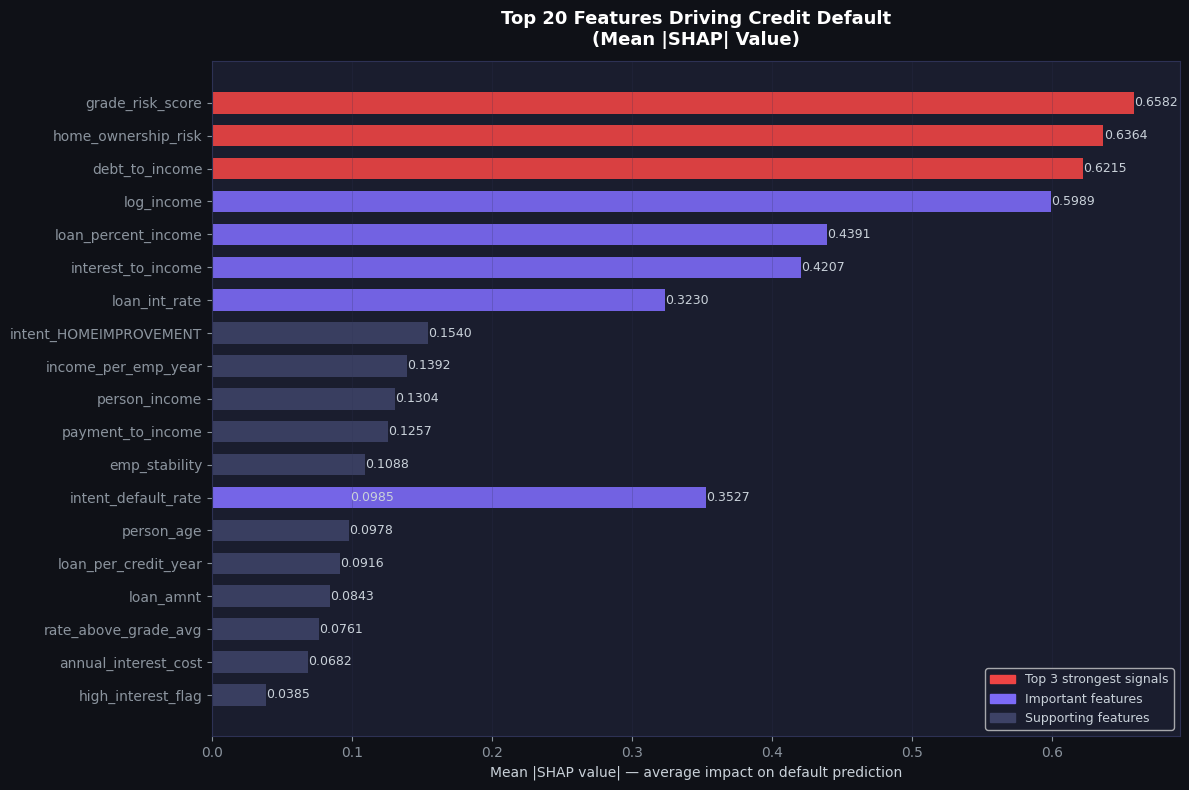

 Saved: ./outputs/shap_global_bar.png

  Top 3 default drivers:
    grade_risk_score: 0.6582
    home_ownership_risk: 0.6364
    debt_to_income: 0.6215


In [25]:
mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=feature_names
).nlargest(20)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

bar_colors = [RED    if i < 3  else
              ACCENT if i < 8  else
              '#3d4266'
              for i in range(len(mean_shap))]

bars = ax.barh(
    mean_shap.index[::-1],
    mean_shap.values[::-1],
    color=bar_colors[::-1],
    alpha=0.9, height=0.65
)

for bar, val in zip(bars, mean_shap.values[::-1]):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, color='#c9d1d9')

ax.set_title(
    'Top 20 Features Driving Credit Default\n(Mean |SHAP| Value)',
    fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Mean |SHAP value| — average impact on default prediction', fontsize=10)
ax.grid(axis='x', alpha=0.3)

patches = [
    mpatches.Patch(color=RED,       label='Top 3 strongest signals'),
    mpatches.Patch(color=ACCENT,    label='Important features'),
    mpatches.Patch(color='#3d4266', label='Supporting features'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('./outputs/shap_global_bar.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" Saved: ./outputs/shap_global_bar.png")
print(f"\n  Top 3 default drivers:")
for feat, val in mean_shap.head(3).items():
    print(f"    {feat}: {val:.4f}")

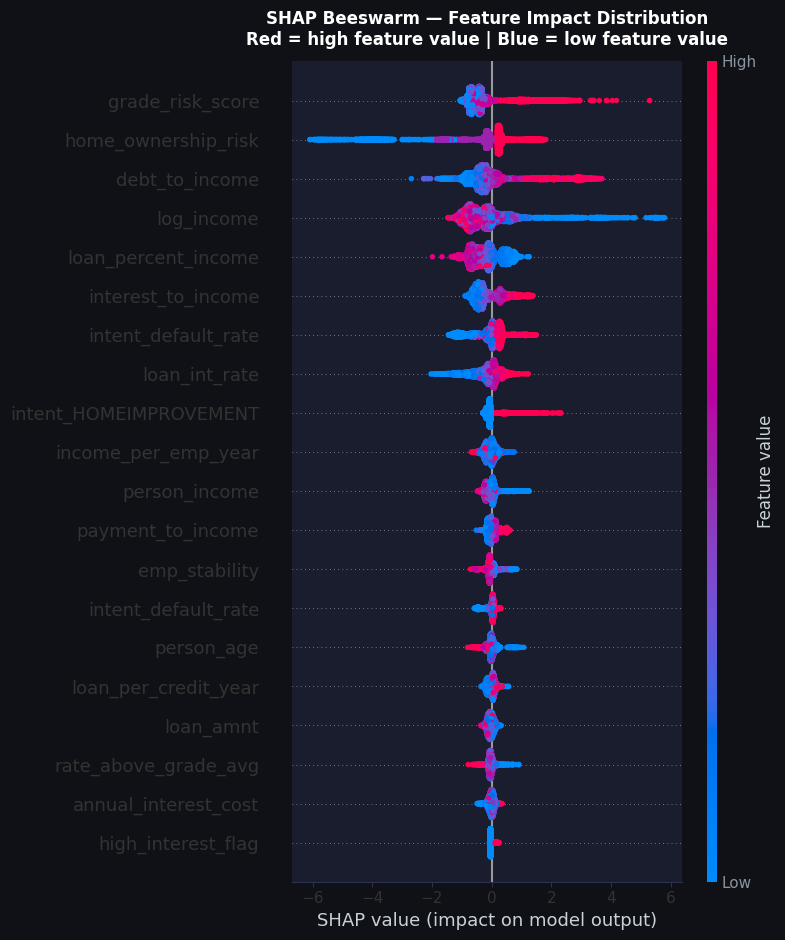

✅  Saved: ./outputs/shap_beeswarm.png


In [26]:
fig = plt.figure(figsize=(12, 9))
fig.patch.set_facecolor('#0f1117')

shap.summary_plot(
    sv, X_test,
    feature_names=feature_names,
    max_display=20,
    show=False,
    plot_type='dot'
)

plt.title(
    'SHAP Beeswarm — Feature Impact Distribution\n'
    'Red = high feature value | Blue = low feature value',
    fontsize=12, fontweight='bold', color='white', pad=12)
plt.tight_layout()
plt.savefig('./outputs/shap_beeswarm.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅  Saved: ./outputs/shap_beeswarm.png")

## Step 2 — Per-Persona SHAP Analysis

Do the two borrower personas default for different reasons?

- **At-Risk Young Borrower** → likely driven by short employment, high loan-to-income, low credit history
- **Cautious Low-Income Borrower** → likely driven by income stress and high interest burden

If the top SHAP features differ between personas, it confirms the clustering was meaningful.


Top 10 SHAP features — Cautious Low-Income Borrower:
    grade_risk_score: 0.6405
    log_income: 0.5776
    home_ownership_risk: 0.4623
    debt_to_income: 0.4558
    interest_to_income: 0.4192
    loan_int_rate: 0.3691
    loan_percent_income: 0.3484
    intent_default_rate: 0.3438
    intent_HOMEIMPROVEMENT: 0.1543
    income_per_emp_year: 0.1519

Top 10 SHAP features — At-Risk Young Borrower:
    home_ownership_risk: 0.9657
    debt_to_income: 0.9348
    grade_risk_score: 0.6915
    log_income: 0.6393
    loan_percent_income: 0.6106
    interest_to_income: 0.4236
    intent_default_rate: 0.3695
    loan_int_rate: 0.2361
    payment_to_income: 0.2122
    intent_HOMEIMPROVEMENT: 0.1535


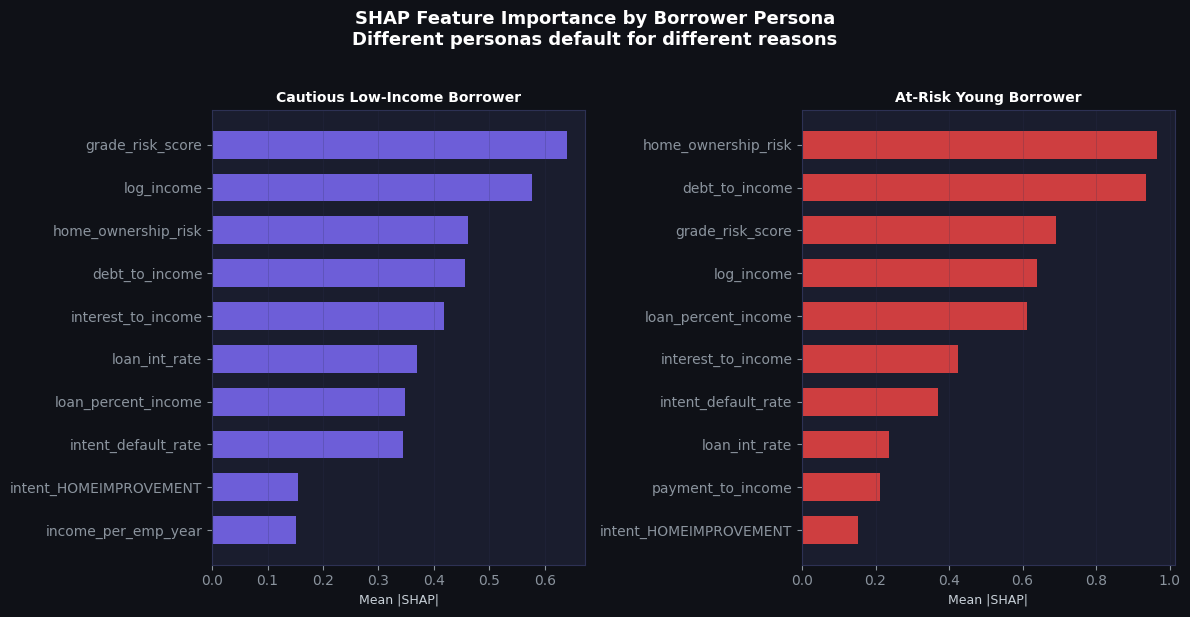

 Saved: ./outputs/shap_by_persona.png


In [30]:
persona_shap = {}

for persona in df_test['persona'].unique():
    mask       = (df_test['persona'] == persona).values
    sv_persona = sv[mask]

    mean_abs = pd.Series(
        np.abs(sv_persona).mean(axis=0),
        index=feature_names
    ).nlargest(10)

    persona_shap[persona] = mean_abs
    print(f"\nTop 10 SHAP features — {persona}:")
    for feat, val in mean_abs.items():
        print(f"    {feat}: {val:.4f}")

# Plot side by side
personas   = list(persona_shap.keys())
n_personas = len(personas)
colors_p   = [ACCENT, RED, GREEN, YELLOW][:n_personas]

fig, axes = plt.subplots(1, n_personas, figsize=(12, 6), sharey=False)
fig.patch.set_facecolor('#0f1117')

if n_personas == 1:
    axes = [axes]

for ax, (persona, color) in zip(axes, zip(personas, colors_p)):
    ax.set_facecolor('#1a1d2e')
    data_p = persona_shap[persona]
    ax.barh(data_p.index[::-1], data_p.values[::-1],
            color=color, alpha=0.85, height=0.65)
    ax.set_title(persona, fontsize=10, fontweight='bold', color='white', wrap=True)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('SHAP Feature Importance by Borrower Persona\n'
             'Different personas default for different reasons',
             fontsize=13, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('./outputs/shap_by_persona.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" Saved: ./outputs/shap_by_persona.png")

Explaining borrower at index 2248
Predicted probability: 100.0%
Actual outcome: DEFAULT


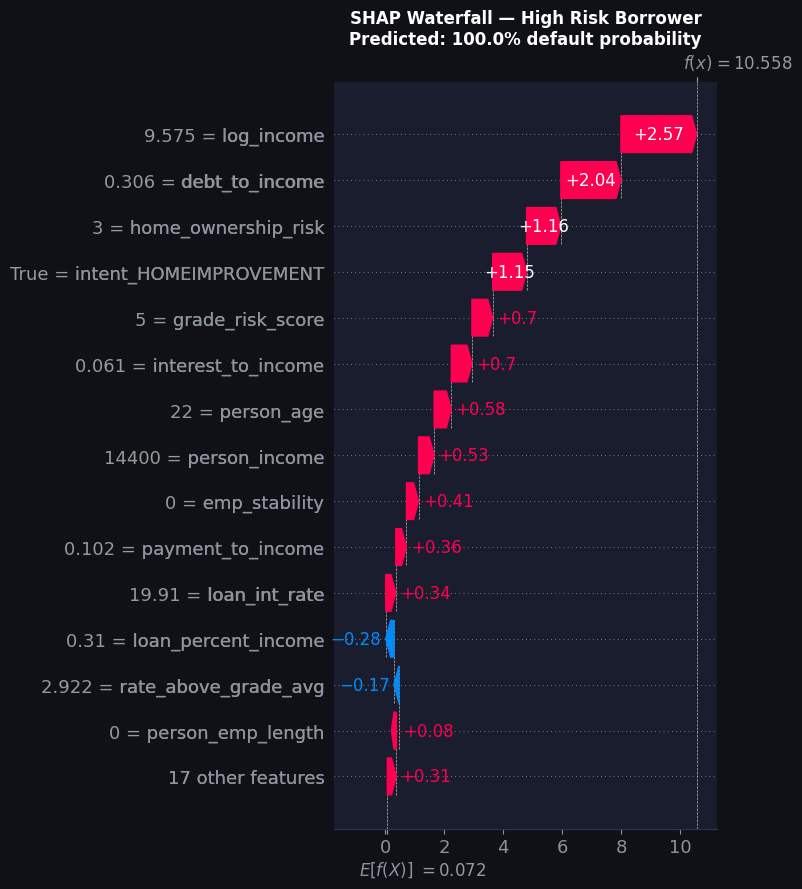

  Saved: ./outputs/shap_waterfall_highrisk.png


In [31]:
all_probs = best_model.predict_proba(X_test)[:, 1]

high_risk_idx = np.where(y_test == 1)[0]
top_idx       = high_risk_idx[np.argmax(all_probs[high_risk_idx])]

print(f"Explaining borrower at index {top_idx}")
print(f"Predicted probability: {all_probs[top_idx]*100:.1f}%")
print(f"Actual outcome: {'DEFAULT' if y_test[top_idx]==1 else 'NO DEFAULT'}")

shap_exp = shap.Explanation(
    values        = sv[top_idx],
    base_values   = explainer.expected_value
                    if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
    data          = X_test[top_idx],
    feature_names = feature_names
)

fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor('#0f1117')
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — High Risk Borrower\n'
          f'Predicted: {all_probs[top_idx]*100:.1f}% default probability',
          fontsize=12, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('./outputs/shap_waterfall_highrisk.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/shap_waterfall_highrisk.png")

## Step 3 — AI Credit Memo via Groq API

This is **Layer 5** — the most modern part of the project.

After SHAP identifies the top risk factors for a borrower, we pass them to Groq (Llama 3) 
to generate a plain-English credit officer memo.

**What this produces:**
- A structured memo a real credit officer would read
- Explains the decision in business language, not ML jargon
- Highlights the top 3 risk factors with context
- Recommends an action with justification


In [ ]:
HUMAN_LABELS = {
    'debt_to_income':        'Debt-to-income ratio',
    'interest_to_income':    'Interest burden relative to income',
    'payment_to_income':     'Monthly payment as % of income',
    'income_per_emp_year':   'Income per year of employment',
    'annual_interest_cost':  'Annual interest cost',
    'loan_per_credit_year':  'Loan size per credit history year',
    'grade_risk_score':      'Loan grade risk score (A=1, G=7)',
    'prior_default':         'Prior default on record',
    'credit_hist_strength':  'Credit history length (log)',
    'rate_above_grade_avg':  'Interest rate vs grade average',
    'high_interest_flag':    'High interest rate flag (>15%)',
    'loan_percent_income':   'Loan as % of annual income',
    'age_group_risk':        'Age-based risk score',
    'emp_stability':         'Employment stability (log years)',
    'short_emp_flag':        'Short employment flag (<2 years)',
    'home_ownership_risk':   'Home ownership stability score',
    'log_income':            'Log annual income',
    'low_income_flag':       'Low income flag (bottom 25%)',
    'intent_default_rate':   'Historical default rate for loan purpose',
    'person_age':            'Borrower age',
    'person_income':         'Annual income',
    'person_emp_length':     'Years of employment',
    'loan_amnt':             'Loan amount requested',
    'loan_int_rate':         'Interest rate',
    'cb_person_cred_hist_length': 'Credit history length (years)',
}

def build_borrower_context(idx, X_data, df_data, sv_data, prob):
    row      = df_data.iloc[idx]
    shap_row = sv_data[idx]
    contrib  = pd.Series(shap_row, index=feature_names)

    top_risk    = contrib.nlargest(5)
    top_protect = contrib.nsmallest(3)

    risk_factors = []
    for feat, val in top_risk.items():
        label   = HUMAN_LABELS.get(feat, feat)
        raw_val = X_data[idx][feature_names.index(feat)]
        risk_factors.append({
            'factor':      label,
            'shap_impact': round(float(val), 4),
            'raw_value':   round(float(raw_val), 3),
            'direction':   'increases default risk'
        })

    protect_factors = []
    for feat, val in top_protect.items():
        label   = HUMAN_LABELS.get(feat, feat)
        raw_val = X_data[idx][feature_names.index(feat)]
        protect_factors.append({
            'factor':      label,
            'shap_impact': round(float(val), 4),
            'raw_value':   round(float(raw_val), 3),
            'direction':   'decreases default risk'
        })

    tier = ('Very High' if prob > 0.70 else
            'High'      if prob > 0.50 else
            'Medium'    if prob > 0.25 else 'Low')

    action = {
        'Very High': 'Decline or refer to financial counselling',
        'High':      'Senior review required + collateral check',
        'Medium':    'Manual underwriter review',
        'Low':       'Auto-approve'
    }[tier]

    return {
        'borrower_profile': {
            'age':              int(row.get('person_age', 0)),
            'annual_income':    int(row.get('person_income', 0)),
            'employment_years': float(row.get('person_emp_length', 0)),
            'home_ownership':   str(row.get('person_home_ownership', '')),
            'loan_amount':      int(row.get('loan_amnt', 0)),
            'loan_intent':      str(row.get('loan_intent', '')),
            'loan_grade':       str(row.get('loan_grade', '')),
            'interest_rate':    float(row.get('loan_int_rate', 0)),
            'persona':          str(row.get('persona', '')),
        },
        'model_decision': {
            'default_probability': round(prob * 100, 1),
            'risk_tier':           tier,
            'recommended_action':  action,
        },
        'risk_factors':       risk_factors,
        'protective_factors': protect_factors,
    }

# Test on high-risk borrower
context = build_borrower_context(top_idx, X_test, df_test, sv, all_probs[top_idx])
print("Borrower context built:")
print(json.dumps(
    context, indent=2,
    default=lambda x: float(x) if isinstance(x, np.floating)
    else int(x) if isinstance(x, np.integer) else x
))

Borrower context built:
{
  "borrower_profile": {
    "age": 22,
    "annual_income": 14400,
    "employment_years": 0.0,
    "home_ownership": "RENT",
    "loan_amount": 4400,
    "loan_intent": "HOMEIMPROVEMENT",
    "loan_grade": "E",
    "interest_rate": 19.91,
    "persona": "At-Risk Young Borrower"
  },
  "model_decision": {
    "default_probability": 100.0,
    "risk_tier": "Very High",
    "recommended_action": "Decline or refer to financial counselling"
  },
  "risk_factors": [
    {
      "factor": "Log annual income",
      "shap_impact": 2.5678,
      "raw_value": 9.575,
      "direction": "increases default risk"
    },
    {
      "factor": "Debt-to-income ratio",
      "shap_impact": 2.0371,
      "raw_value": 0.306,
      "direction": "increases default risk"
    },
    {
      "factor": "Home ownership stability score",
      "shap_impact": 1.1599,
      "raw_value": 3.0,
      "direction": "increases default risk"
    },
    {
      "factor": "intent_HOMEIMPROVEMENT",

In [32]:
def generate_credit_memo(borrower_context: dict, api_key: str) -> str:
    """
    Generate a professional credit officer memo using Groq API.
    Model: openai/gpt-oss-120b (current Groq recommendation for 70B-class tasks)
    """
    client = Groq(api_key=api_key)

    prompt = f"""You are a senior credit risk officer at a lending institution.
You have received the following automated risk assessment for a loan application.
Write a professional credit officer memo based on this data.

BORROWER ASSESSMENT DATA:
{json.dumps(
    borrower_context, indent=2,
    default=lambda o:
        float(o) if isinstance(o, np.floating)
        else int(o) if isinstance(o, np.integer)
        else o.tolist() if isinstance(o, np.ndarray)
        else str(o)
)}

Write a structured memo with these exact sections:

CREDIT OFFICER MEMO
═══════════════════════════════════════

APPLICANT SUMMARY
[2-3 sentences describing the borrower profile in plain English]

RISK ASSESSMENT
Default Probability: [X]%
Risk Tier: [tier]
Recommended Action: [action]

KEY RISK FACTORS
[List the top 3 risk factors as numbered points.
For each: explain what the factor is, what the borrower's value is,
and why it increases default risk. Use plain business language — no ML jargon.]

MITIGATING FACTORS
[List 2-3 protective factors that work in the borrower's favour]

RECOMMENDATION
[1 paragraph: clear recommendation with business justification.
Reference specific numbers from the borrower profile.]

Write professionally. Be specific with numbers.
Do not mention SHAP, XGBoost, or any ML terminology."""

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=1000
    )

    return response.choices[0].message.content

print(" generate_credit_memo() defined")

 generate_credit_memo() defined


## Generate Memos for 3 Borrower Profiles

In [34]:
all_probs_test = best_model.predict_proba(X_test)[:, 1]

# Case 1 — Very high risk actual default
high_mask = y_test == 1
case1_idx = np.where(high_mask)[0][np.argmax(all_probs_test[high_mask])]

# Case 2 — Low risk actual no-default
low_mask  = y_test == 0
case2_idx = np.where(low_mask)[0][np.argmin(all_probs_test[low_mask])]

# Case 3 — Borderline (model uncertain)
case3_idx = np.argmin(np.abs(all_probs_test - 0.50))

cases = {
    'high_risk_defaulter': case1_idx,
    'low_risk_payer':      case2_idx,
    'borderline_case':     case3_idx,
}

memos = {}
for case_name, idx in cases.items():
    prob    = all_probs_test[idx]
    context = build_borrower_context(idx, X_test, df_test, sv, prob)

    print(f"\n{'='*56}")
    print(f"  Generating memo: {case_name}")
    print(f"  Probability: {prob*100:.1f}%  |  "
          f"Actual: {'DEFAULT' if y_test[idx]==1 else 'NO DEFAULT'}")
    print(f"{'='*56}\n")

    memo = generate_credit_memo(context, API_KEY)
    memos[case_name] = memo
    print(memo)

    with open(f'./outputs/memos/{case_name}_memo.txt', 'w', encoding='utf-8') as f:
         f.write(memo)

print("\n  All 3 memos saved to ./outputs/memos/")


  Generating memo: high_risk_defaulter
  Probability: 100.0%  |  Actual: DEFAULT

CREDIT OFFICER MEMO  
═══════════════════════════════════════  

**APPLICANT SUMMARY**  
The applicant is a 22‑year‑old renter with no prior employment history and an annual income of $14,400. They are seeking a $4,400 loan (approximately 31% of annual income) for home‑improvement purposes and have been assigned a grade “E” loan with an interest rate of 19.91%.

**RISK ASSESSMENT**  
Default Probability: **100%**  
Risk Tier: **Very High**  
Recommended Action: **Decline or refer to financial counselling**

**KEY RISK FACTORS**  
1. **Low annual income** – The borrower’s income of $14,400 places them in the lowest income bracket for our portfolio. Limited earnings reduce the ability to meet monthly debt obligations, markedly raising default risk.  
2. **High debt‑to‑income (DTI) ratio** – With a DTI of 30.6%, a large share of the applicant’s income is already committed to existing debt. A DTI above 30% i